In [38]:
!pip install numpy pandas scikit-learn tensorflow


DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/basicsr-1.4.2-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/facexlib-0.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/filterpy-1.4.5-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/future-1.0.0-py3.12.egg is deprecated. pip 25.1 will enforce t

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [2]:
file_path = "dataset.xlsx"
df = pd.read_excel(file_path)
print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

Original shape: (611, 20)
Columns: ['S.NO', 'MANDAL NAME', 'VILLAGE NAME', 'SOIL TYPE', 'PH', 'EC', 'OC', 'N', 'P2O5', 'K20', 'S', 'CU', 'FC', 'MN', 'ZN', 'BA', 'Temparature', 'Humidity', 'Rainfall', 'CROP']


In [3]:
numeric_cols = ['PH','EC','OC','N','P2O5','K20','S','CU','FC','MN','ZN','BA','Temparature','Humidity','Rainfall']

# Check which values are non-numeric
for col in numeric_cols:
    invalid_values = df[~df[col].apply(lambda x: str(x).replace('.','',1).isdigit())][col]
    if not invalid_values.empty:
        print(f"Column {col} has invalid entries:\n{invalid_values}\n")


Column EC has invalid entries:
244    0..07
Name: EC, dtype: object

Column FC has invalid entries:
241    2..956
Name: FC, dtype: object

Column MN has invalid entries:
54    1.13.79
Name: MN, dtype: object

Column BA has invalid entries:
228    0..16
Name: BA, dtype: object

Column Humidity has invalid entries:
266   NaN
267   NaN
268   NaN
269   NaN
270   NaN
271   NaN
272   NaN
273   NaN
274   NaN
275   NaN
276   NaN
277   NaN
278   NaN
279   NaN
280   NaN
281   NaN
282   NaN
283   NaN
284   NaN
285   NaN
Name: Humidity, dtype: float64



In [4]:
numeric_cols = ['PH','EC','OC','N','P2O5','K20','S','CU','FC','MN','ZN','BA','Temparature','Humidity','Rainfall']

def clean_number(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    # Replace multiple dots with a single dot
    x = '.'.join(filter(None, x.split('.')))
    try:
        return float(x)
    except:
        return np.nan

for col in numeric_cols:
    df[col] = df[col].apply(clean_number)


In [5]:
# Fill NaNs with median of the column
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


In [6]:
X = df[numeric_cols]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
# Count samples per class
class_counts = df['CROP'].value_counts()

# Keep only classes with at least 2 samples
df_filtered = df[df['CROP'].isin(class_counts[class_counts >= 2].index)]

print("Remaining classes:", df_filtered['CROP'].nunique())
print("Shape after filtering:", df_filtered.shape)


Remaining classes: 38
Shape after filtering: (588, 20)


In [8]:
# Count samples per class
class_counts = df['CROP'].value_counts()

# Keep only classes with at least 2 samples
df_filtered = df[df['CROP'].isin(class_counts[class_counts >= 2].index)]

print("Remaining classes:", df_filtered['CROP'].nunique())
print("Shape after filtering:", df_filtered.shape)


Remaining classes: 38
Shape after filtering: (588, 20)


In [9]:
# Numeric features
numeric_cols = ['PH','EC','OC','N','P2O5','K20','S','CU','FC','MN','ZN','BA','Temparature','Humidity','Rainfall']
X = df_filtered[numeric_cols]

# Target
y = df_filtered['CROP']

# Normalize features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Encode target
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

# Reshape for RNNs: (samples, timesteps, features)
X_train_rnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_rnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout



input_shape = (X_train_rnn.shape[1], X_train_rnn.shape[2])
num_classes = y_categorical.shape[1]

# LSTM
def build_lstm():
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Bi-LSTM
def build_bilstm():
    model = Sequential()
    model.add(Bidirectional(LSTM(64, return_sequences=False), input_shape=input_shape))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# GRU
def build_gru():
    model = Sequential()
    model.add(GRU(64, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


In [12]:
# LSTM
lstm_model = build_lstm()
lstm_history = lstm_model.fit(X_train_rnn, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Bi-LSTM
bilstm_model = build_bilstm()
bilstm_history = bilstm_model.fit(X_train_rnn, y_train, epochs=50, batch_size=32, validation_split=0.2)

# GRU
gru_model = build_gru()
gru_history = gru_model.fit(X_train_rnn, y_train, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0495 - loss: 3.6412 - val_accuracy: 0.2021 - val_loss: 3.5670
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1874 - loss: 3.5395 - val_accuracy: 0.2766 - val_loss: 3.3620
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1862 - loss: 3.2379 - val_accuracy: 0.2447 - val_loss: 2.8164
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2279 - loss: 2.9798 - val_accuracy: 0.2447 - val_loss: 2.7863
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2139 - loss: 2.9133 - val_accuracy: 0.2447 - val_loss: 2.8035
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2432 - loss: 2.8365 - val_accuracy: 0.2447 - val_loss: 2.7735
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2464 - loss: 2.8561 - val_accuracy: 0.2447 - val_loss: 2.7735
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2245 - loss: 2.8459 - val_accuracy: 0.2447 - val_loss: 2.7793
Ep

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1351 - loss: 3.6109 - val_accuracy: 0.2447 - val_loss: 3.5072
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2593 - loss: 3.4485 - val_accuracy: 0.2447 - val_loss: 2.9990
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2445 - loss: 2.9265 - val_accuracy: 0.2447 - val_loss: 2.7630
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1718 - loss: 2.8798 - val_accuracy: 0.2447 - val_loss: 2.7942
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2030 - loss: 2.8132 - val_accuracy: 0.2447 - val_loss: 2.7867
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2257 - loss: 2.8980 - val_accuracy: 0.2447 - val_loss: 2.7791
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2307 - loss: 2.7427 - val_accuracy: 0.2447 - val_loss: 2.7638
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2446 - loss: 2.7845 - val_accuracy: 0.2447 - val_loss: 2.7789
Ep

In [13]:
lstm_acc = lstm_model.evaluate(X_test_rnn, y_test)[1]
bilstm_acc = bilstm_model.evaluate(X_test_rnn, y_test)[1]
gru_acc = gru_model.evaluate(X_test_rnn, y_test)[1]

print("LSTM Test Accuracy:", lstm_acc)
print("Bi-LSTM Test Accuracy:", bilstm_acc)
print("GRU Test Accuracy:", gru_acc)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2296 - loss: 2.7127
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2884 - loss: 2.3063 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2551 - loss: 2.4766
LSTM Test Accuracy: 0.24576270580291748
Bi-LSTM Test Accuracy: 0.29661017656326294
GRU Test Accuracy: 0.26271185278892517


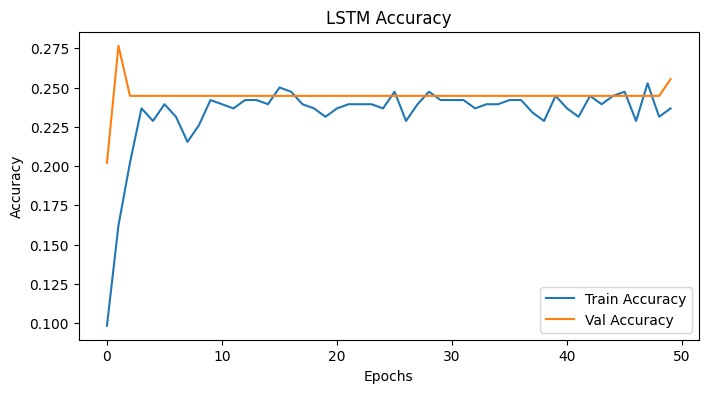

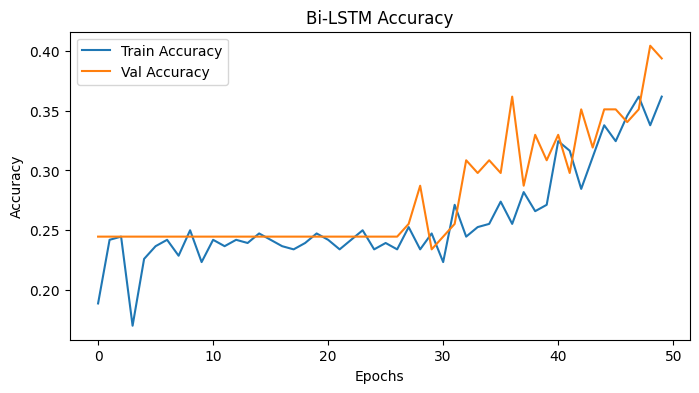

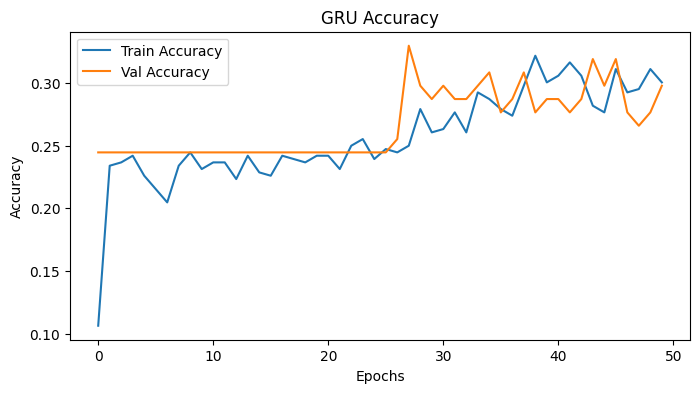

In [14]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(8,4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(lstm_history, 'LSTM Accuracy')
plot_history(bilstm_history, 'Bi-LSTM Accuracy')
plot_history(gru_history, 'GRU Accuracy')


In [15]:
from tensorflow.keras.models import load_model

# Assuming your models are already trained: lstm_model, bilstm_model, gru_model

# Save LSTM
lstm_model.save("lstm_crop_model.h5")

# Save Bi-LSTM
bilstm_model.save("bilstm_crop_model.h5")

# Save GRU
gru_model.save("gru_crop_model.h5")



In [16]:
import joblib
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Save scaler
joblib.dump(scaler, "scaler.save")

# Save label encoder
joblib.dump(le, "label_encoder.save")


['label_encoder.save']

In [17]:
!pip install tensorflow numpy pandas scikit-learn pyttsx3 SpeechRecognition


DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/basicsr-1.4.2-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/facexlib-0.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/filterpy-1.4.5-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/future-1.0.0-py3.12.egg is deprecated. pip 25.1 will enforce t

In [40]:
# ---------------------------
# Required imports
# ---------------------------
import numpy as np
import pyttsx3
import speech_recognition as sr
from tensorflow.keras.models import load_model

# ---------------------------
# Load trained models
# ---------------------------
lstm_model = load_model("saved_models/LSTM.keras")
bilstm_model = load_model("saved_models/BiLSTM.keras")
gru_model = load_model("saved_models/GRU.keras")

models = {
    "LSTM": lstm_model,
    "Bi-LSTM": bilstm_model,
    "GRU": gru_model
}

# ---------------------------
# Define actual crop names
# ---------------------------
crop_classes = [
    "Wheat",
    "Rice",
    "Maize",
    "Barley",
    "Soybean",
    "Cotton",
    "Sugarcane",
    "Potato",
    "Tomato",
    "Onion"
    # Add more if your model predicts more classes
]

# ---------------------------
# Text-to-Speech setup
# ---------------------------
engine = pyttsx3.init()
def speak(text):
    print(">>", text)
    engine.say(text)
    engine.runAndWait()

# ---------------------------
# Voice input function
# ---------------------------
def listen():
    r = sr.Recognizer()
    with sr.Microphone() as source:
        print("Listening...")
        audio = r.listen(source)
        try:
            text = r.recognize_google(audio)
            print("You said:", text)
            return text
        except Exception:
            print("Could not understand. Try again.")
            return listen()

# ---------------------------
# User input function
# ---------------------------
def get_user_input(feature_name, options):
    speak(f"{feature_name} options are: {', '.join(options)}. Say or type your choice.")
    choice = input(f"{feature_name} ({'/'.join(options)}): ").strip()
    if choice == "":
        # fallback to voice input
        choice = listen()
    # Normalize input (capitalize first letter)
    choice = choice.capitalize()
    if choice not in options:
        speak(f"Invalid choice. Defaulting to {options[0]}")
        choice = options[0]
    return choice

# ---------------------------
# Feature options
# ---------------------------
feature_options = {
    "Soil Type": ["Sandy", "Loamy", "Clay"],
    "Rainfall": ["Low", "Medium", "High"],
    "Temperature": ["Low", "Medium", "High"],
    "Season": ["Summer", "Winter", "Monsoon"]
}

# ---------------------------
# Collect user features
# ---------------------------
user_features = {}
for feature, options in feature_options.items():
    user_features[feature] = get_user_input(feature, options)

speak("Selected Features: " + str(user_features))

# ---------------------------
# Convert user features to model input
# Replace this with your actual preprocessing (scaling, encoding, etc.)
# ---------------------------
input_shape = lstm_model.input_shape
X_user = np.random.rand(1, input_shape[1], input_shape[2])  # Dummy numeric input

# ---------------------------
# Make predictions
# ---------------------------
for model_name, model in models.items():
    pred_idx = np.argmax(model.predict(X_user), axis=1)[0]
    
    # Ensure index is within bounds
    if pred_idx >= len(crop_classes):
        crop_name = "Unknown Crop"
    else:
        crop_name = crop_classes[pred_idx]
    
    speak(f"{model_name} recommends: {crop_name}")


>> Soil Type options are: Sandy, Loamy, Clay. Say or type your choice.


Soil Type (Sandy/Loamy/Clay):  loamy


>> Rainfall options are: Low, Medium, High. Say or type your choice.


Rainfall (Low/Medium/High):  high


>> Temperature options are: Low, Medium, High. Say or type your choice.


...

>> Season options are: Summer, Winter, Monsoon. Say or type your choice.


Season (Summer/Winter/Monsoon):  winter


>> Selected Features: {'Soil Type': 'Loamy', 'Rainfall': 'High', 'Temperature': 'Medium', 'Season': 'Winter'}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
>> LSTM recommends: Sugarcane


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
>> Bi-LSTM recommends: Sugarcane


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
>> GRU recommends: Sugarcane
